## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [ ]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

In [115]:
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
npr.seed(123)
df = pd.read_csv('~/data/data_000637.txt')
print(df)
df.info()

         HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
0           1     0          123  3869200167        2374        26
1           1     0          124  3869200167        2374        27
2           1     0           63  3869200167        2553        28
3           1     0           64  3869200167        2558        19
4           1     0           64  3869200167        2760        25
...       ...   ...          ...         ...         ...       ...
1310715     1     0           62  3869211171         762        14
1310716     1     1            4  3869211171         763        11
1310717     1     0           64  3869211171         764         0
1310718     1     0          139  3869211171         769         0
1310719     1     0           61  3869211171         762        18

[1310720 rows x 6 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310720 entries, 0 to 1310719
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype
---  ------   

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [35]:
# Question 1
n = 25_000
dfn = pd.read_csv('~/data/data_000637.txt', nrows = n)
print(dfn)

       HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
0         1     0          123  3869200167        2374        26
1         1     0          124  3869200167        2374        27
2         1     0           63  3869200167        2553        28
3         1     0           64  3869200167        2558        19
4         1     0           64  3869200167        2760        25
...     ...   ...          ...         ...         ...       ...
24995     1     0           72  3869200416        1932        14
24996     1     0           54  3869200416        1932        28
24997     1     1           64  3869200416        2018        20
24998     1     1            6  3869200416        2098         4
24999     1     1            3  3869200416        2101         6

[25000 rows x 6 columns]


In [151]:
# Question 2
orbit_value = df["ORBIT_CNT"].iloc[0]
one_orbit = df[df["ORBIT_CNT"] == orbit_value] # keep only rows from that orbit
x = one_orbit["BX_COUNTER"].nunique() # .nunique() : counts distinct BX values 
print("number of BX in one orbit", x,'\n')
one_orbit["BX_COUNTER"].min(), one_orbit["BX_COUNTER"].max()

number of BX in one orbit 34 



(2374, 3187)

In [5]:
bx_orbits = df.groupby("ORBIT_CNT")["BX_COUNTER"].nunique()
print(bx_orbits)

ORBIT_CNT
3869200167     34
3869200168     68
3869200169     95
3869200170     80
3869200171     83
             ... 
3869211167    153
3869211168     86
3869211169    137
3869211170    103
3869211171     19
Name: BX_COUNTER, Length: 11001, dtype: int64


In [34]:
# Question 3 (precise solution)
n_orbits = df["ORBIT_CNT"].nunique()
BX_time = 25e-9
BX_per_orbit = 3564
orbit_time = BX_time * BX_per_orbit
total_time = n_orbits * orbit_time
print(total_time, "per seconds")

0.9801890999999999 per seconds


In [50]:
# Estimate solution 
N = len(df)
orbits_in_sample = dfn["ORBIT_CNT"].nunique()
est_orbits = orbits_in_sample/n * N 
total_time = est_orbits * orbit_time
print(total_time,"per seconds"

1.16785152 per seconds


In [92]:
# Question 4
BX_NS = 25
BX_PER_ORBIT = 3564
ORBIT_NS = BX_PER_ORBIT * BX_NS
TC_NS = 25/32
orbit_0 = df["ORBIT_CNT"].min()
df["absolute_time_ns"] = (df["ORBIT_CNT"] - orbit_0) * ORBIT_NS + df["BX_COUNTER"] * BX_NS + df["TDC_MEAS"] * TC_NS 
print(df)

         HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS  \
0           1     0          123  3869200167        2374        26   
1           1     0          124  3869200167        2374        27   
2           0     0           63  3869200167        2553        28   
3           1     0           64  3869200167        2558        19   
4           1     0           64  3869200167        2760        25   
...       ...   ...          ...         ...         ...       ...   
1310715     1     0           62  3869211171         762        14   
1310716     0     1            4  3869211171         763        11   
1310717     1     0           64  3869211171         764         0   
1310718     1     0          139  3869211171         769         0   
1310719     1     0           61  3869211171         762        18   

         absolute_time_ns  
0            5.937031e+04  
1            5.937109e+04  
2            6.384688e+04  
3            6.396484e+04  
4            6.9019

In [91]:
# QUESTION 5
df["HEAD"] = npr.randint(0, 2, len(df))

In [107]:
# QUESTION 6
new_df = pd.DataFrame(df[df["HEAD"] == 1])
print(new_df)

         HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS  \
0           1     0          123  3869200167        2374        26   
1           1     0          124  3869200167        2374        27   
3           1     0           64  3869200167        2558        19   
4           1     0           64  3869200167        2760        25   
5           1     0           63  3869200167        2762         4   
...       ...   ...          ...         ...         ...       ...   
1310713     1     0           64  3869211171         758        18   
1310715     1     0           62  3869211171         762        14   
1310717     1     0           64  3869211171         764         0   
1310718     1     0          139  3869211171         769         0   
1310719     1     0           61  3869211171         762        18   

         absolute_time_ns  
0            5.937031e+04  
1            5.937109e+04  
3            6.396484e+04  
4            6.901953e+04  
5            6.9053

In [152]:
n_df = df.loc[df["HEAD"] == 1].copy
print(n_df)

<bound method NDFrame.copy of          HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
0           1     0          123  3869200167        2374        26
1           1     0          124  3869200167        2374        27
2           1     0           63  3869200167        2553        28
3           1     0           64  3869200167        2558        19
4           1     0           64  3869200167        2760        25
...       ...   ...          ...         ...         ...       ...
1310715     1     0           62  3869211171         762        14
1310716     1     1            4  3869211171         763        11
1310717     1     0           64  3869211171         764         0
1310718     1     0          139  3869211171         769         0
1310719     1     0           61  3869211171         762        18

[1310720 rows x 6 columns]>


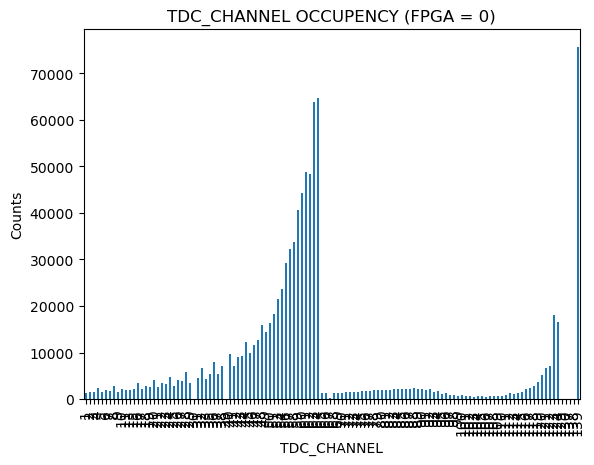

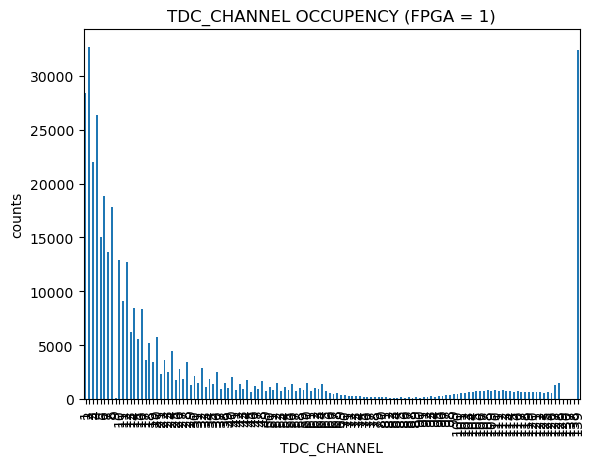

In [117]:
# QUESTION 7
occ_fpga_0 = df[df["FPGA"] == 0].groupby("TDC_CHANNEL").size()
occ_fpga_1 = df[df["FPGA"] == 1].groupby("TDC_CHANNEL").size()
# .groupby() : Pandas splits the table into groups, one group per unique TDC channel, .size() : “How many rows are in each group?”, So for each TDC channel, Pandas counts:
# how many times that channel appears in the data
plt.figure()
occ_fpga_0.plot(kind="bar")
plt.title("TDC_CHANNEL OCCUPENCY (FPGA = 0)")
plt.xlabel("TDC_CHANNEL")
plt.ylabel("Counts")
plt.show()

plt.figure()
occ_fpga_1.plot(kind="bar")
plt.title("TDC_CHANNEL OCCUPENCY (FPGA = 1)")
plt.xlabel("TDC_CHANNEL")
plt.ylabel("counts")
plt.show()

In [126]:
# Question 8
noisy_channels = df.groupby("TDC_CHANNEL").size().sort_values(ascending=False).head(3)
print(noisy_channels)

TDC_CHANNEL
139    108059
64      66020
63      64642
dtype: int64


In [165]:
# Question 9
orbits_with_139 = df[df["TDC_CHANNEL"] == 139]["ORBIT_CNT"].nunique()
#.unique() returns each distinct value only once, in the order they first appear.
orbits_with_139

10976